# Barren Plateaus in Stochastic Circuits

Parameterized quantum circuits are known to suffer from barren plateaus: the variance of cost function gradients decays exponentially with the number of qubits, making optimization difficult for large systems.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from torx import DiscretePCircuit, PCNOT, PNOT, StateVectorSimulator
from tqdm import tqdm

## Setup

We use a brick-layer circuit architecture, analogous to the hardware-efficient ansatz studied in quantum barren plateau literature:

Each layer consists of:
- `PNOT(theta)` on every p-bit (single-site randomization)
- `PCNOT(theta)` between nearest neighbors (two-site correlations)

The cost function is $C = P(|0\ldots0))$, the probability of the all-zeros configuration after circuit execution. The gradient is taken with respect to the first gate parameter, which must propagate through the entire subsequent circuit.

In [2]:
mpl.rcParams.update(
    {
        "axes.labelsize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "savefig.dpi": 300,
        "text.usetex": False,
    }
)

In [3]:
PBIT_RANGE = list(range(2, 15))
DEPTH_RANGE = list(range(2, 15))
NUM_SAMPLES = 100
SEED = 42

sim = StateVectorSimulator()


def make_circuit(thetas, num_pbits, depth):
    gates = []
    idx = 0
    for _ in range(depth):
        for q in range(num_pbits):
            gates.append(PNOT(theta=thetas[idx], sites=q))
            idx += 1
        for q in range(num_pbits - 1):
            gates.append(PCNOT(theta=thetas[idx], sites=[q, q + 1]))
            idx += 1
    return DiscretePCircuit(gates)


def count_params(num_pbits, depth):
    return depth * (2 * num_pbits - 1)


def measure_gradient_variance(
    num_pbits,
    depth,
    num_samples,
    key,
    theta_min=-jnp.pi,
    theta_max=jnp.pi,
):
    n_params = count_params(num_pbits, depth)
    init_state = jnp.zeros(2**num_pbits).at[0].set(1.0)

    template = make_circuit(jnp.zeros(n_params), num_pbits, depth)

    def cost_fn(thetas):
        new_gates = [
            eqx.tree_at(lambda g: g.theta, g, thetas[i])
            for i, g in enumerate(template.gates)
        ]
        compiled = StateVectorSimulator.build_circuit(DiscretePCircuit(new_gates))
        return sim.density(compiled, init_state)[0]

    @jax.jit
    def batch_grads(all_thetas):
        return jax.vmap(lambda t: jax.grad(cost_fn)(t)[0])(all_thetas)

    all_thetas = jax.random.uniform(
        key, (num_samples, n_params), minval=theta_min, maxval=theta_max
    )
    grads = batch_grads(all_thetas)

    return jnp.var(grads), jnp.mean(grads)

In [4]:
key = jax.random.key(SEED)
pbits = np.array(PBIT_RANGE)
depths = np.array(DEPTH_RANGE)

total_points = len(PBIT_RANGE) * len(DEPTH_RANGE)
var_grid = {}

pbar = tqdm(total=total_points, desc="Random init grid")
for n in PBIT_RANGE:
    for d in DEPTH_RANGE:
        key, subkey = jax.random.split(key)
        var, _ = measure_gradient_variance(n, d, NUM_SAMPLES, subkey)
        var_grid[(n, d)] = var
        pbar.set_postfix(n=n, d=d, var=f"{var:.2e}")
        pbar.update(1)
pbar.close()

Random init grid:  78%|███████▊  | 132/169 [36:25<18:22, 29.81s/it, d=3, n=12, var=1.02e-09] E0331 02:28:42.840531 2574897 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0331 02:28:42.962291 2574891 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0331 02:28:43.064303 2574886 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Random init grid:  99%|█████████▉| 168/169 [1:01:14<00:59, 59.61s/it, d=13, n=14, var=1.85e-15]E0331 02:54:14.331002 2574919 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0331 02:54:14.433278 2574910 cuda_timer.cc:87] 

In [5]:
# Extract slices for figures
min_depth = min(DEPTH_RANGE)
var_depth_min = np.array([var_grid[(n, min_depth)] for n in PBIT_RANGE])
var_depthN = np.array([var_grid[(n, n)] for n in PBIT_RANGE])

fit_depth_min = np.polyfit(pbits, np.log(var_depth_min + 1e-30), 1)
fit_depthN = np.polyfit(pbits, np.log(var_depthN + 1e-30), 1)

print("Exponential fit slopes:")
print(f"  Depth={min_depth}:  {fit_depth_min[0]:.3f}")
print(f"  Depth=n:  {fit_depthN[0]:.3f}")

Exponential fit slopes:
  Depth=2:  -1.387
  Depth=n:  -2.298


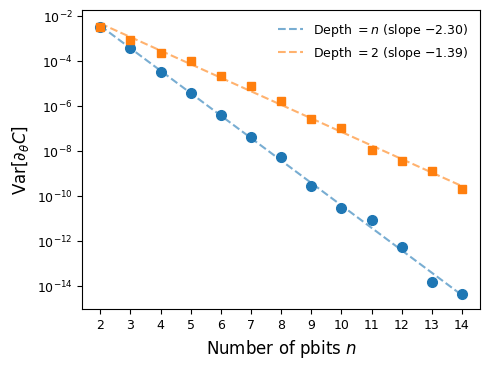

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.8))

ax.semilogy(pbits, var_depthN, "o", color="C0", ms=7, zorder=3)
ax.semilogy(
    pbits,
    np.exp(fit_depthN[0] * pbits + fit_depthN[1]),
    "--",
    color="C0",
    alpha=0.6,
    label=rf"Depth $= n$ (slope ${fit_depthN[0]:.2f}$)",
)
ax.semilogy(pbits, var_depth_min, "s", color="C1", ms=6, zorder=3)
ax.semilogy(
    pbits,
    np.exp(fit_depth_min[0] * pbits + fit_depth_min[1]),
    "--",
    color="C1",
    alpha=0.6,
    label=rf"Depth $= {min_depth}$ (slope ${fit_depth_min[0]:.2f}$)",
)

ax.set_xlabel("Number of pbits $n$")
ax.set_ylabel(r"Var$[\partial_\theta C]$")
ax.legend(frameon=False)
ax.set_xticks(pbits)
fig.tight_layout()
plt.show()

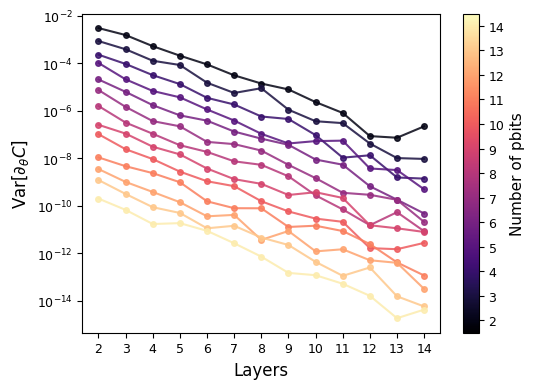

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))

cmap = plt.cm.magma
norm = mpl.colors.Normalize(vmin=min(PBIT_RANGE) - 0.5, vmax=max(PBIT_RANGE) + 0.5)

for n in PBIT_RANGE:
    color = cmap(norm(n))
    variances = [var_grid[(n, d)] for d in DEPTH_RANGE]
    ax.semilogy(depths, variances, "o-", color=color, ms=4, lw=1.5, alpha=0.85)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Number of pbits", fontsize=11)
cbar.set_ticks(PBIT_RANGE)

ax.set_xlabel("Layers")
ax.set_ylabel(r"Var$[\partial_\theta C]$")
ax.set_xticks(DEPTH_RANGE)
fig.tight_layout()
plt.show()